<a href="https://colab.research.google.com/github/VSShu25/ML-Basic/blob/main/VSShuNoteForOtusFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Для учебного проекта ознакомимся с потреблением сахара в странах за большой период времени (60+ лет) и попробуем установить зависимость уровня ожирения в этих странах от уровня потребления сахара.

Для работы был выбран датасет с сайта Kaggle.

Гипотеза заключается в том, что высокий уровень ожирения (выше среднего значения) напрямую связано с уровнем потребления сахара.

Загрузим наши данные и ознакомимся с ними. Импортируем инструменты.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
import warnings
#import kaggle
#import kagglehub

from google.colab import drive
#kaggle.api.authenticate()
#path = kagglehub.dataset_download("global-sugar-consumption-trends-19602023")
# тут не получилось, апи кэгла сменил версию, снаскоку не гуглится корректный вариант, пока убрала
#print("Path to dataset files:", path)

# Настройка графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

drive.mount('/content/drive', force_remount=True)

# warnings.filterwarnings('ignore')

Mounted at /content/drive


Теперь переходим к исходным данным
Загружаем датасет и смотрим на состав данных

In [3]:
dataPath = '/content/drive/My Drive/datasets/sugar_consumption_dataset.csv'
df = pd.read_csv(dataPath)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       10000 non-null  object 
 1   Year                          10000 non-null  int64  
 2   Country_Code                  10000 non-null  object 
 3   Continent                     10000 non-null  object 
 4   Region                        10000 non-null  object 
 5   Population                    10000 non-null  float64
 6   GDP_Per_Capita                10000 non-null  float64
 7   Per_Capita_Sugar_Consumption  10000 non-null  float64
 8   Total_Sugar_Consumption       10000 non-null  float64
 9   Sugar_From_Sugarcane          10000 non-null  float64
 10  Sugar_From_Beet               10000 non-null  float64
 11  Sugar_From_HFCS               10000 non-null  float64
 12  Sugar_From_Other              10000 non-null  float64
 13  Pr

Затем посмотрим на описание каждой представленной метрики

In [4]:
df.describe()

,Year,Population,GDP_Per_Capita,Per_Capita_Sugar_Consumption,Total_Sugar_Consumption,Sugar_From_Sugarcane,Sugar_From_Beet,Sugar_From_HFCS,Sugar_From_Other,Processed_Food_Consumption,Avg_Daily_Sugar_Intake,Diabetes_Prevalence,Obesity_Rate,Sugar_Imports,Sugar_Exports,Avg_Retail_Price_Per_Kg,Gov_Tax,Gov_Subsidies,Education_Campaign,Urbanization_Rate,Climate_Conditions,Sugarcane_Production_Yield
count,10000.000000,1.000000e+04,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000,9469.000000,10000.000000,9480.000000,10000.000000,10000.000000,10000.000000
mean,1991.330300,1.501189e+08,25242.491756,37.626027,5.650157e+06,70.028543,22.494559,29.811113,-22.334215,155.294166,103.095314,9.349124,22.355718,5.040963e+06,5.077761e+06,2.747125,0.150914,0.297500,0.406962,49.973144,2.977100,65.251931
std,18.424086,8.646170e+07,14193.053646,18.733654,4.599203e+06,11.481251,10.207287,17.242892,22.988417,83.677159,51.330211,3.795188,10.090557,2.890586e+06,2.886414e+06,1.302997,0.357983,0.457181,0.491294,23.185861,1.415831,20.185192
min,1960.000000,1.005004e+06,500.417394,5.017558,7.387572e+03,50.005200,5.003532,0.001761,-84.188301,10.028391,13.748109,2.135502,5.001991,3.658518e+02,1.577075e+02,0.500030,0.000000,0.000000,0.000000,10.018786,1.000000,30.002468
25%,1976.000000,7.434980e+07,13219.345523,21.386174,1.882590e+06,60.072363,13.544087,14.746013,-38.633165,81.785601,58.598117,6.053038,13.698372,2.509690e+06,2.570209e+06,1.620856,0.000000,0.000000,0.000000,29.374395,2.000000,47.375830
50%,1991.000000,1.500741e+08,25155.568950,37.878147,4.369083e+06,70.167342,22.532868,30.101299,-22.413240,155.910019,103.786122,9.326412,22.258420,5.064198e+06,5.103455e+06,2.736859,0.000000,0.000000,0.000000,50.201101,3.000000,65.571891
75%,2007.000000,2.250870e+08,37558.130715,54.003484,8.484738e+06,80.007973,31.448762,44.571011,-5.925863,228.076059,147.969545,12.657526,31.006182,7.552546e+06,7.606691e+06,3.872086,0.000000,1.000000,1.000000,70.072238,4.000000,82.512623
max,2023.000000,2.999917e+08,49997.014954,69.991881,2.090366e+07,89.994688,39.999721,59.998558,40.710226,299.934874,191.777755,16.547123,39.997246,9.999894e+06,9.999107e+06,4.999483,1.000000,1.000000,1.000000,89.998222,5.000000,99.993296


Оценим качество наших данных. Заполним пропуски медианными значениями, сгруппированными по странам.

In [5]:
df['Gov_Tax'] = df.groupby('Country')['Gov_Tax'].transform(
    lambda x: x.fillna(x.median())
)
# Мода — наиболее часто встречающееся значение в группе (0 или 1). Логично заполнять пропуски самым распространённым значением.
df['Education_Campaign'] = df.groupby('Country')['Education_Campaign'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 0)
)

Проводим анализ выбросов и распределения. Для достижения целей исследования возьмем признаки:

1. Obesity_Rate                   - уровень ожирения - целевая переменна
2. Per_Capita_Sugar_Consumption   - потребление сахара на душу населения
3. Total_Sugar_Consumption        - общее потребление сахара
4. Processed_Food_Consumption     - потребление переработанных продуктов
5. Diabetes_Prevalence            - распространненость диабета
6. Education_Campaign             - наличие образовательных программ
7. Urbanization_Rate              - уровень урбанизации     
Признак Avg_Daily_Sugar_Intake  исключим, поскольку он по смыслу очень близок к признаку Total_Sugar_Consumption.
Проверим, верна ли первоначальная гипотеза о зависимости уровня ожирения от потребления сахара на душу населения, либо уровень ожирения наилучшим образом будет предсказываться по значениям других признаков.







ОПИСАТЕЛЬНАЯ СТАТИСТИКА ПО КЛЮЧЕВЫМ ПРИЗНАКАМ:
       Per_Capita_Sugar_Consumption  Obesity_Rate  Total_Sugar_Consumption  \
count                  10000.000000  10000.000000             1.000000e+04   
mean                      37.626027     22.355718             5.650157e+06   
std                       18.733654     10.090557             4.599203e+06   
min                        5.017558      5.001991             7.387572e+03   
25%                       21.386174     13.698372             1.882590e+06   
50%                       37.878147     22.258420             4.369083e+06   
75%                       54.003484     31.006182             8.484738e+06   
max                       69.991881     39.997246             2.090366e+07   

       Processed_Food_Consumption  Diabetes_Prevalence  Education_Campaign  \
count                10000.000000         10000.000000        10000.000000   
mean                   155.294166             9.349124            0.385800   
std            

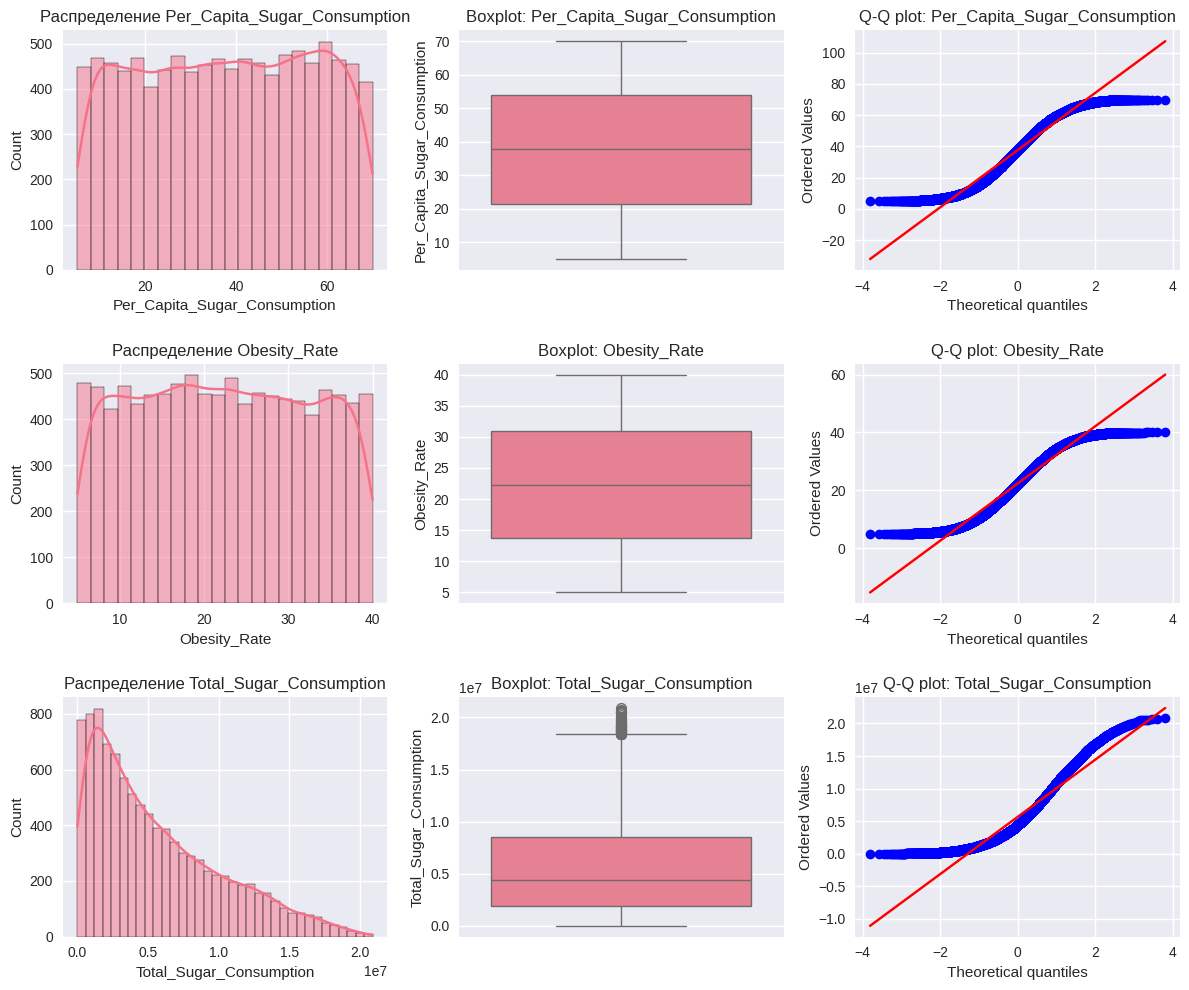

In [6]:
SUGAR_COL = 'Per_Capita_Sugar_Consumption' # потребление сахара на душу населения
OBESITY_COL = 'Obesity_Rate' # уровень ожирения
TOTAL_SUGAL_COL = 'Total_Sugar_Consumption' # общее потребление сахара
PROC_FOOD_COL = 'Processed_Food_Consumption' #  потребление переработанных продуктов
DIAB_PREV_COL = 'Diabetes_Prevalence' # распространненость диабета
EDUC_COMP_COL = 'Education_Campaign' # наличие образовательных программ
URBAN_COL = 'Urbanization_Rate' # уровень урбанизации
print(f"\nОПИСАТЕЛЬНАЯ СТАТИСТИКА ПО КЛЮЧЕВЫМ ПРИЗНАКАМ:")
print(df[[SUGAR_COL, OBESITY_COL, TOTAL_SUGAL_COL, PROC_FOOD_COL, DIAB_PREV_COL, EDUC_COMP_COL, URBAN_COL]].describe())

# Функция для обнаружения выбросов методом IQR
def detect_outliers_iqr(series):
  Q1 = series.quantile(0.25)
  Q3 = series.quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = series[(series < lower_bound) | (series > upper_bound)]
  return outliers.index.tolist(), lower_bound, upper_bound

# Поиск выбросов
obesity_outliers, _, _ = detect_outliers_iqr(df[OBESITY_COL])
sugar_outliers, _, _ = detect_outliers_iqr(df[SUGAR_COL])
total_sug_outliers, _, _ =  detect_outliers_iqr(df[TOTAL_SUGAL_COL])
proc_food_outliers, _, _ = detect_outliers_iqr(df[PROC_FOOD_COL])
diab_prev__outliers, _, _ =  detect_outliers_iqr(df[DIAB_PREV_COL])
educ_comp_outliers, _, _ = detect_outliers_iqr(df[EDUC_COMP_COL])
urban_outliers, _, _ =  detect_outliers_iqr(df[URBAN_COL])

print(f"\n\nВыбросы в уровне ожирения: {len(obesity_outliers)} наблюдений")
print(f"Выбросы в потреблении сахара: {len(sugar_outliers)} наблюдений")
print(f"Выбросы в общем потреблении сахара: {len(total_sug_outliers)} наблюдений")
print(f"Выбросы в потреблении переработанных продуктов: {len(proc_food_outliers)} наблюдений")
print(f"Выбросы в наличии образовательных программ: {len(educ_comp_outliers)} наблюдений")
print(f"Выбросы в уровне урбанизации: {len(urban_outliers)} наблюдений\n\n")

# Визуальный анализ распределения и выбросов
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

# Гистограмма + KDE для сахара на душу населения
sns.histplot(df[SUGAR_COL], kde=True, ax=axes[0,0])
axes[0,0].set_title(f'Распределение {SUGAR_COL}')
# Boxplot для сахара
sns.boxplot(y=df[SUGAR_COL], ax=axes[0,1])
axes[0,1].set_title(f'Boxplot: {SUGAR_COL}')
# Q-Q plot для сахара (проверка нормальности)
stats.probplot(df[SUGAR_COL], dist="norm", plot=axes[0,2])
axes[0,2].set_title(f'Q-Q plot: {SUGAR_COL}')

# Аналогично для ожирения
sns.histplot(df[OBESITY_COL], kde=True, ax=axes[1,0])
axes[1,0].set_title(f'Распределение {OBESITY_COL}')
sns.boxplot(y=df[OBESITY_COL], ax=axes[1,1])
axes[1,1].set_title(f'Boxplot: {OBESITY_COL}')
stats.probplot(df[OBESITY_COL], dist="norm", plot=axes[1,2])
axes[1,2].set_title(f'Q-Q plot: {OBESITY_COL}')

# Аналогично для общего потребления сахара
sns.histplot(df[TOTAL_SUGAL_COL], kde=True, ax=axes[2,0])
axes[2,0].set_title(f'Распределение {TOTAL_SUGAL_COL}')
sns.boxplot(y=df[TOTAL_SUGAL_COL], ax=axes[2,1])
axes[2,1].set_title(f'Boxplot: {TOTAL_SUGAL_COL}')
stats.probplot(df[TOTAL_SUGAL_COL], dist="norm", plot=axes[2,2])
axes[2,2].set_title(f'Q-Q plot: {TOTAL_SUGAL_COL}')

plt.tight_layout()
plt.show()

Далее проведем анализ корреляции ключевых признаков. Для начала используем коэффициент Пирсона.


КОРРЕЛЯЦИОННЫЙ АНАЛИЗ:
КОРРЕЛЯЦИИ С УРОВНЕМ ОЖИРЕНИЯ (OBESITY_RATE)
                              Pearson  Spearman  Kendall  Mutual_Information
Diabetes_Prevalence           -0.0042   -0.0040  -0.0027              0.0221
Education_Campaign            -0.0100   -0.0099  -0.0081                 NaN
Per_Capita_Sugar_Consumption   0.0020    0.0019   0.0012              0.0071
Processed_Food_Consumption    -0.0113   -0.0113  -0.0076              0.0051
Total_Sugar_Consumption       -0.0068   -0.0007  -0.0005              0.0000
Urbanization_Rate              0.0078    0.0079   0.0052              0.0000


<Figure size 1200x800 with 0 Axes>

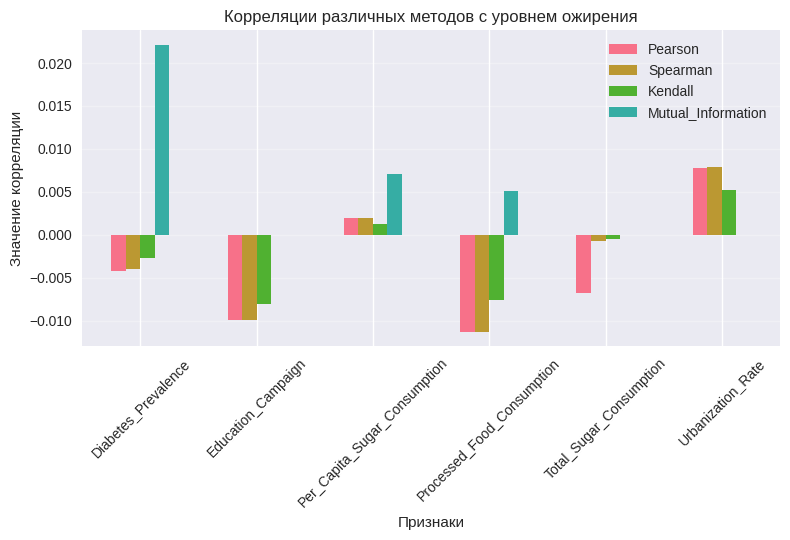

In [7]:
print("\nКОРРЕЛЯЦИОННЫЙ АНАЛИЗ:")

# Список всех признаков (исключаем целевую переменную)
feature_columns = [
    SUGAR_COL,
    TOTAL_SUGAL_COL,
    PROC_FOOD_COL,
    DIAB_PREV_COL,
    EDUC_COMP_COL,
    URBAN_COL
]

def calculate_correlations(df, target_col, feature_cols):
    results = {}

    # Корреляция Пирсона
    pearson_corr = df[feature_cols + [target_col]].corr(method='pearson')[target_col]
    results['Pearson'] = pearson_corr.drop(target_col)

    # Корреляция Спирмана
    spearman_corr = df[feature_cols + [target_col]].corr(method='spearman')[target_col]
    results['Spearman'] = spearman_corr.drop(target_col)

    # Корреляция Кендалла
    kendall_corr = df[feature_cols + [target_col]].corr(method='kendall')[target_col]
    results['Kendall'] = kendall_corr.drop(target_col)

    # Mutual Information
    X = df[feature_cols]
    y = df[target_col]

    # Удаляем категориальные признаки для Mutual Information (если есть)
    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    if EDUC_COMP_COL in numeric_features:
        numeric_features.remove(EDUC_COMP_COL)

    mi_scores = mutual_info_regression(
        X[numeric_features],
        y,
        random_state=42
    )

    results['Mutual_Information'] = pd.Series(
        mi_scores,
        index=numeric_features
    )

    return pd.DataFrame(results)

# Рассчитываем корреляции
correlation_results = calculate_correlations(
    df=df,
    target_col=OBESITY_COL,
    feature_cols=feature_columns
)

# Выводим результаты
print("КОРРЕЛЯЦИИ С УРОВНЕМ ОЖИРЕНИЯ (OBESITY_RATE)")
print("=" * 60)
print(correlation_results.round(4))

# Визуализация результатов
plt.figure(figsize=(12, 8))
correlation_results.plot(kind='bar', rot=45)
plt.title('Корреляции различных методов с уровнем ожирения')
plt.ylabel('Значение корреляции')
plt.xlabel('Признаки')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Полученные коэффициенты корреляции указывают на слабую связь между признаками либо ее отсутствие. Попробуем другой способ.

<Axes: >

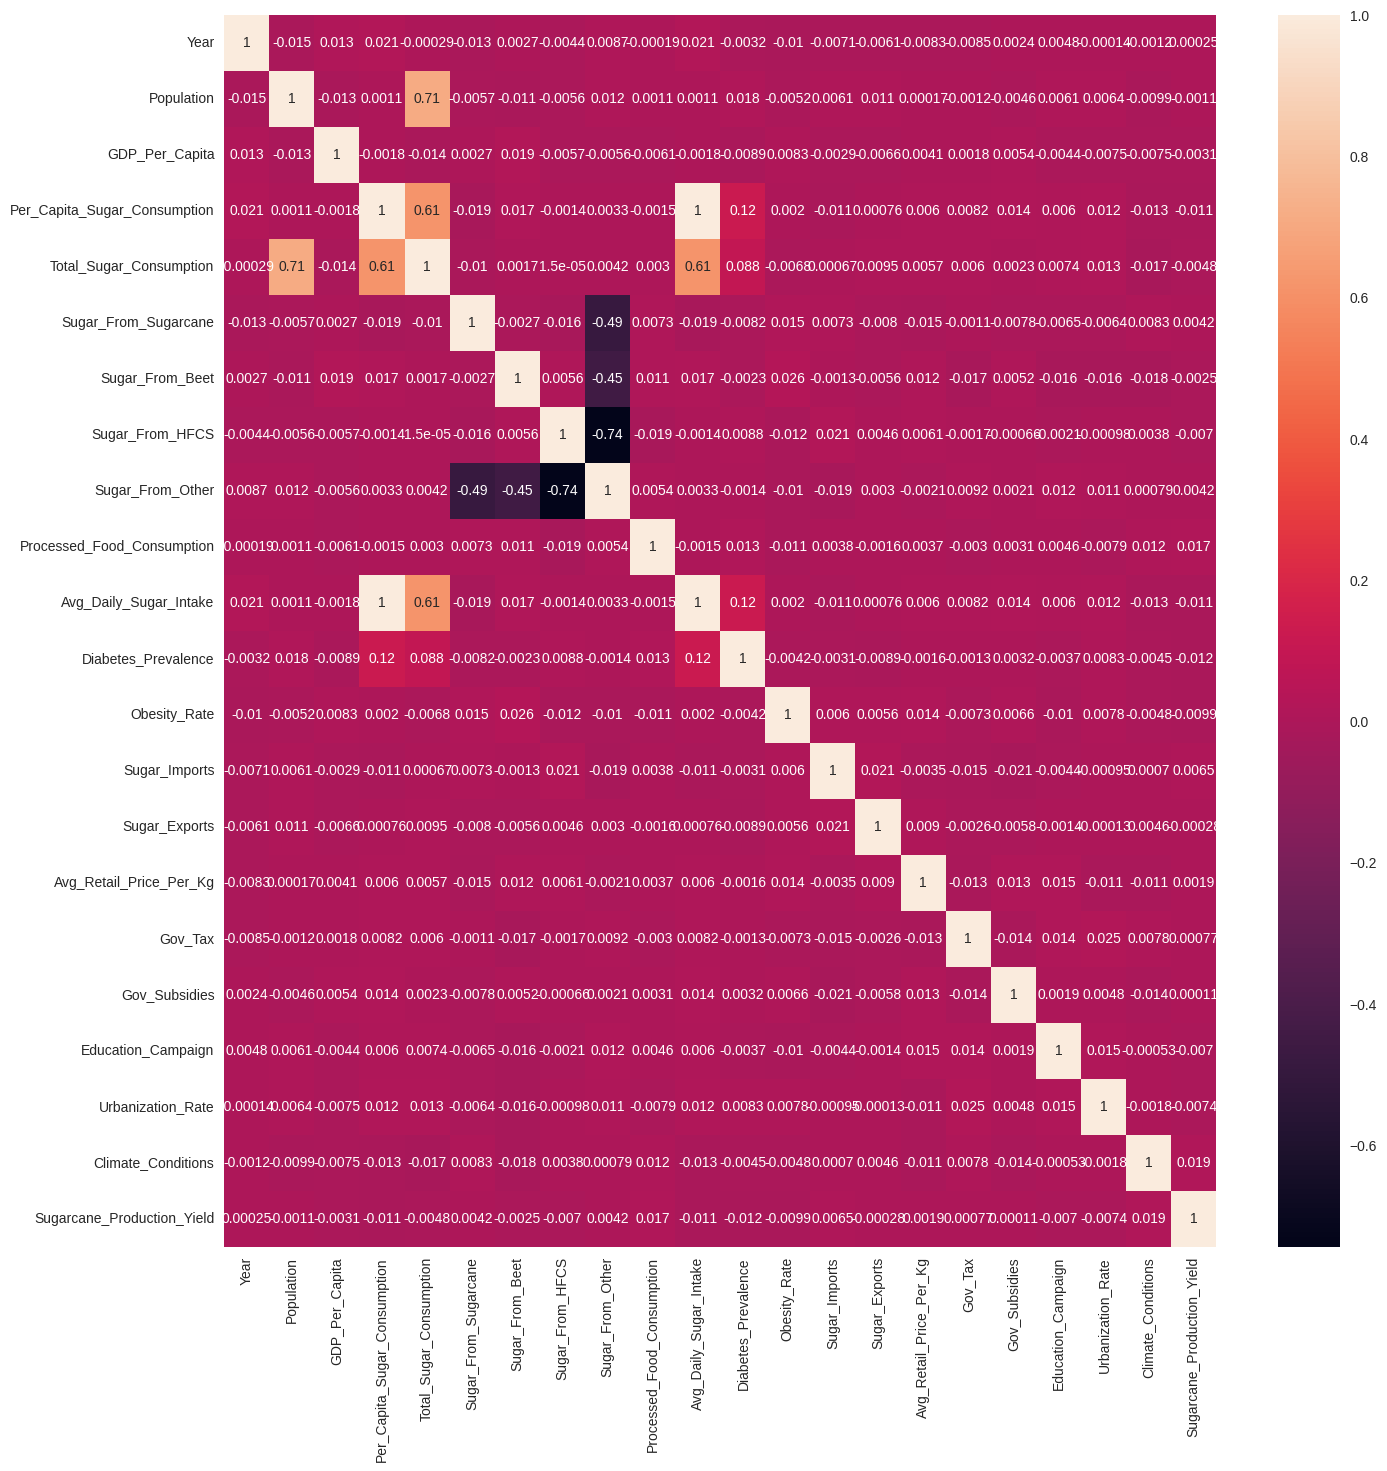

In [8]:
X = df.select_dtypes(exclude=['object']).copy()
# Матрица корреляции
correlation_matrix = X.corr()
# Выводим признаки на тепловую карту
plt.figure(figsize= (16, 16))
sns.heatmap(correlation_matrix, annot = True)

Предварительные выводы по зависимостям признаков.

Целевая переменная "уровень ожирения" не связана с потреблением сахара на душу населения.
По тепловой карте корреляции значимые показатели установлены между численностью населения и общим потреблением сахара (0,71), что не представляет ценности для нашего исследования. Также установлена корреляция между средним ежедневным потреблением сахара и общим потреблением сахара (0,61), что также не представляет ценности для нашего исследования. Видим слабую корреляцию (0,12) между распространенностью диабета и потреблением сахара на душу населения. Исследованные данные не выявляют никаких связей уровня потребления сахара ни с уровнем ожирения, ни с распространением диабета. Корреляция Пирсона указывает, что уровень ожирения сильнее связан с уровнем урбанизации, чем с потреблением сахара на душу населения, однако, значение коэффициента ничтожное.



 Отсутствие корреляции может быть связано с тем, что ожирение определяется множеством факторов, значения которых не учтено в настоящем датасете. Дополнительные факторы ожирения: калорийность питания, физическая активность, доход населения, возрастная структура, доступность медицины.

Однако, пробуем установить наличие зависимостей при помощи scatter plot для визуализации.

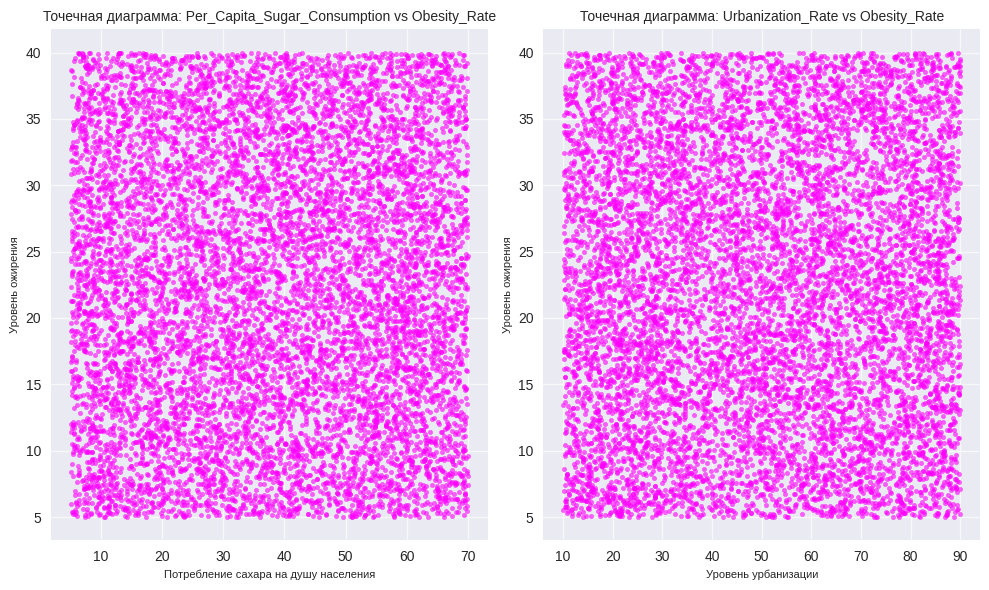

In [9]:
# Создаём фигуру с двумя subplot в одной строке
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Первый subplot: Per_Capita_Sugar_Consumption vs Obesity_Rate
axes[0].scatter(
    df['Per_Capita_Sugar_Consumption'],
    df['Obesity_Rate'],
    alpha=0.6,      # Прозрачность точек
    color='magenta',  # Цвет точек
    s=10            # Размер точек
)
axes[0].set_xlabel('Потребление сахара на душу населения', fontsize=8)
axes[0].set_ylabel('Уровень ожирения', fontsize=8)
axes[0].set_title('Точечная диаграмма: Per_Capita_Sugar_Consumption vs Obesity_Rate', fontsize=10)
axes[0].grid(True, alpha=0.7)  # Добавляем сетку для первого subplot

# Второй subplot: Urbanization_Rate vs Obesity_Rate
axes[1].scatter(
    df['Urbanization_Rate'],
    df['Obesity_Rate'],
    alpha=0.6,      # Прозрачность точек
    color='magenta',  # Цвет точек
    s=10            # Размер точек
)
axes[1].set_xlabel('Уровень урбанизации', fontsize=8)
axes[1].set_ylabel('Уровень ожирения', fontsize=8)
axes[1].set_title('Точечная диаграмма: Urbanization_Rate vs Obesity_Rate', fontsize=10)
axes[1].grid(True, alpha=0.7)  # Добавляем сетку для второго subplot

# Корректируем отступы, чтобы графики не накладывались
plt.tight_layout()
plt.show()


Построение scatter plot не позволяет визуально определить наличие зависимости. Наблюдаем отсутствие корреляции. Точки распределены хаотично, нет явного тренда. Вывод: потребление сахара и уровень ожирения, уровень урбанизации и уровень ожирения явно не показывают корреляции на графиках.

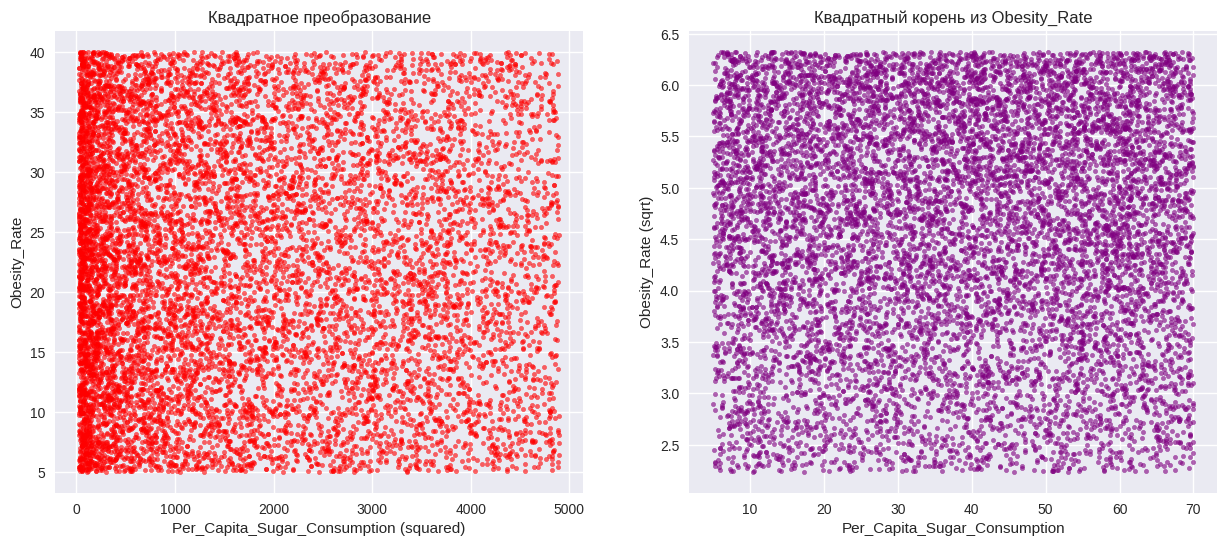

In [10]:
# Квадратное преобразование
X['Per_Capita_Sugar_Consumption_squared'] = X['Per_Capita_Sugar_Consumption'] ** 2

# Квадратный корень
X['Obesity_Rate_sqrt'] = np.sqrt(np.abs(X['Obesity_Rate']))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(X['Per_Capita_Sugar_Consumption_squared'], X['Obesity_Rate'], alpha=0.6, color='red', s=10)
axes[0].set_xlabel('Per_Capita_Sugar_Consumption (squared)')
axes[0].set_ylabel('Obesity_Rate')
axes[0].set_title('Квадратное преобразование')

axes[1].scatter(X['Per_Capita_Sugar_Consumption'], X['Obesity_Rate_sqrt'], alpha=0.6, color='purple', s=10)
axes[1].set_xlabel('Per_Capita_Sugar_Consumption')
axes[1].set_ylabel('Obesity_Rate (sqrt)')
axes[1].set_title('Квадратный корень из Obesity_Rate')
plt.show()

Пробуем применить стандартизацию (Z‑score). Не, ну а вдруг.

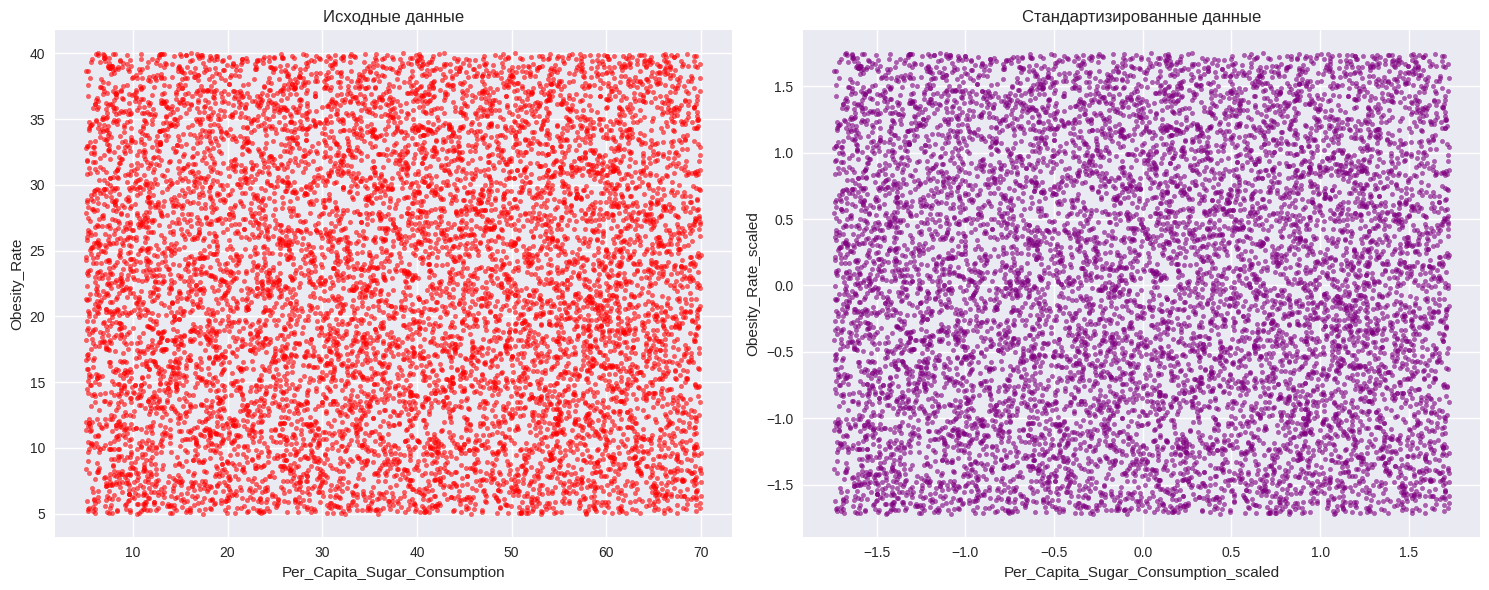

In [11]:
# Инициализируем StandardScaler
scaler = StandardScaler()

Y = df.select_dtypes(exclude=['object']).copy()
# Применяем стандартизацию
df_scaled = pd.DataFrame(
    scaler.fit_transform(Y), columns=Y.columns
)
# посмотрим, что изменилось
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Исходные данные
axes[0].scatter(Y['Per_Capita_Sugar_Consumption'], Y['Obesity_Rate'], alpha=0.6, color='red', s=10)
axes[0].set_title('Исходные данные')
axes[0].set_xlabel('Per_Capita_Sugar_Consumption')
axes[0].set_ylabel('Obesity_Rate')

# Стандартизированные данные
axes[1].scatter(df_scaled['Per_Capita_Sugar_Consumption'], df_scaled['Obesity_Rate'], alpha=0.6, color='purple', s=10)
axes[1].set_title('Стандартизированные данные')
axes[1].set_xlabel('Per_Capita_Sugar_Consumption_scaled')
axes[1].set_ylabel('Obesity_Rate_scaled')

plt.tight_layout()
plt.show()

Наблюдаем отсутствие корреляции. Точки распределены хаотично, нет явного тренда. Вывод: всё еще мимо цели. Поскольку значимой корреляции пока не выявлено, расширим диапазон поиска, добавив больше признаков. Попробуем поработать со степенью и посмотреть на корреляцию.

In [12]:
from sklearn.preprocessing import PolynomialFeatures

# Создание полиномиальных признаков (степень 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(df[['Per_Capita_Sugar_Consumption','Total_Sugar_Consumption','Processed_Food_Consumption','Diabetes_Prevalence','Education_Campaign','Urbanization_Rate']])
poly_feature_names = poly.get_feature_names_out(['Per_Capita_Sugar_Consumption','Total_Sugar_Consumption','Processed_Food_Consumption','Diabetes_Prevalence','Education_Campaign','Urbanization_Rate'])

# Создаём новый датасет с полиномиальными признаками
df_poly = pd.DataFrame(X_poly, columns=poly_feature_names)

print("Созданные полиномиальные признаки:")
print(df_poly.columns.tolist())

# Анализ корреляций между полиномиальными признаками и целевой переменной
target = df['Obesity_Rate']  # в нашем случае используем Obesity_Rate как целевую
correlations = {}
for col in df_poly.columns:
    corr = np.corrcoef(df_poly[col], target)[0, 1]
    correlations[col] = corr

# Сортируем по абсолютной величине корреляции (от самых сильных связей)
sorted_correlations = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

# Выводим коррелирующие признаки по силе связи
print("Признаки по силе корреляции с Obesity_Rate:")
for feature, corr_value in sorted_correlations[:10]:
    print(f"{feature}: {corr_value:.4f}")

Созданные полиномиальные признаки:
['Per_Capita_Sugar_Consumption', 'Total_Sugar_Consumption', 'Processed_Food_Consumption', 'Diabetes_Prevalence', 'Education_Campaign', 'Urbanization_Rate', 'Per_Capita_Sugar_Consumption^2', 'Per_Capita_Sugar_Consumption Total_Sugar_Consumption', 'Per_Capita_Sugar_Consumption Processed_Food_Consumption', 'Per_Capita_Sugar_Consumption Diabetes_Prevalence', 'Per_Capita_Sugar_Consumption Education_Campaign', 'Per_Capita_Sugar_Consumption Urbanization_Rate', 'Total_Sugar_Consumption^2', 'Total_Sugar_Consumption Processed_Food_Consumption', 'Total_Sugar_Consumption Diabetes_Prevalence', 'Total_Sugar_Consumption Education_Campaign', 'Total_Sugar_Consumption Urbanization_Rate', 'Processed_Food_Consumption^2', 'Processed_Food_Consumption Diabetes_Prevalence', 'Processed_Food_Consumption Education_Campaign', 'Processed_Food_Consumption Urbanization_Rate', 'Diabetes_Prevalence^2', 'Diabetes_Prevalence Education_Campaign', 'Diabetes_Prevalence Urbanization_Rate',

Выводы по найденным коэффициентам корреляции: не наблюдается. Справочно: менее 0.3 слабая связь, от 0.3 до 0.6 умеренная связь, более 0.7 сильная связь. Будем пробовать построить модель полиномиальной регрессии на наших данных.

In [13]:
from sklearn.model_selection import train_test_split

# Разделяем признаки и целевую переменную
Z = df.select_dtypes(exclude=['object']).copy()
XZ = Z[['Per_Capita_Sugar_Consumption','Total_Sugar_Consumption','Processed_Food_Consumption','Diabetes_Prevalence','Education_Campaign','Urbanization_Rate']].values
yZ = Z['Obesity_Rate'].values


# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    XZ, yZ, test_size=0.2, random_state=42
)
# Создаём и обучаем скалер на обучающей выборке
scaler_std = StandardScaler()
X_train_scaled_std = scaler_std.fit_transform(X_train)
# применяем к тестовой выборке
X_test_scaled_std = scaler_std.transform(X_test)

# Преобразуем обратно в DataFrame для наглядности
X_train_std_df = pd.DataFrame(X_train_scaled_std,
    columns=['Per_Capita_Sugar_Consumption','Total_Sugar_Consumption','Processed_Food_Consumption','Diabetes_Prevalence','Education_Campaign','Urbanization_Rate'])
print("\nПосле стандартизации (StandardScaler):")
print(X_train_std_df.describe())

#
def train_polynomial_regression(X_train_scaled, X_test_scaled, scaler_name):
    # Создаём полиномиальные признаки (степень 2)
    polypol = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = polypol.fit_transform(X_train_scaled)
    X_test_poly = polypol.transform(X_test_scaled)

    # Обучаем модель
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Предсказания
    y_pred = model.predict(X_test_poly)

    # Метрики качества
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)  # RMSE — корень из MSE
    mae = mean_absolute_error(y_test, y_pred)  # Средняя абсолютная ошибка

    r2 = r2_score(y_test, y_pred)

    print(f"\nРезультаты для {scaler_name}:")
    print(f"MSE (средняя квадратичная ошибка): {mse:.4f}")
    print(f"RMSE (корень из MSE): {rmse:.4f}")
    print(f"MAE (средняя абсолютная ошибка): {mae:.4f}")
    print(f"R² (коэффициент детерминации): {r2:.4f}")

    return model, polypol, y_pred

# Обучаем модель со стандартизацией
model_std, poly_std, y_pred_std = train_polynomial_regression(
    X_train_scaled_std, X_test_scaled_std, "StandardScaler"
)



После стандартизации (StandardScaler):
       Per_Capita_Sugar_Consumption  Total_Sugar_Consumption  \
count                  8.000000e+03             8.000000e+03   
mean                  -4.098055e-15            -3.144152e-16   
std                    1.000063e+00             1.000063e+00   
min                   -1.747113e+00            -1.228342e+00   
25%                   -8.678662e-01            -8.172520e-01   
50%                    1.154543e-02            -2.770152e-01   
75%                    8.707460e-01             6.219748e-01   
max                    1.726308e+00             3.291581e+00   

       Processed_Food_Consumption  Diabetes_Prevalence  Education_Campaign  \
count                8.000000e+03         8.000000e+03        8.000000e+03   
mean                -6.454393e-15         2.458478e-15        1.598721e-17   
std                  1.000063e+00         1.000063e+00        1.000063e+00   
min                 -1.730401e+00        -1.897842e+00       -7.945573e

Полученные результаты показывают крайне низкое значение метрик качества при использовании модели полиномиальной регрессии. При этом увеличение степени полинома не дает улучшения метрик. Поищем другие модели. Хотя интуиция говорит, что бесполезно искать черную кошку в темной комнате, особенно если ее там нет.
Но для очистки совести попробуем все же применить деревья решений.

ОЦЕНКА КАЧЕСТВА МОДЕЛИ DecisionTreeRegressor деревья решений для регресии 
Тестовая выборка:
  Среднеквадратическая ошибка (MSE): 102.84
  Корень из MSE (RMSE): 10.14
  Средняя абсолютная ошибка (MAE): 8.73
  Медианная абсолютная ошибка: 8.82
  Коэффициент детерминации (R²): -0.0060

Обучающая выборка:
  MSE: 100.64
  R²: 0.0102

АНАЛИЗ ПЕРЕОБУЧЕНИЯ
------------------------------
Переобучения не обнаружено (разница R² в пределах нормы)

ВАЖНОСТЬ ПРИЗНАКОВ
------------------------------
                        Признак  Важность
0  Per_Capita_Sugar_Consumption  0.363673
1       Total_Sugar_Consumption  0.306101
5             Urbanization_Rate  0.157778
2    Processed_Food_Consumption  0.120658
4            Education_Campaign  0.051789
3           Diabetes_Prevalence  0.000000


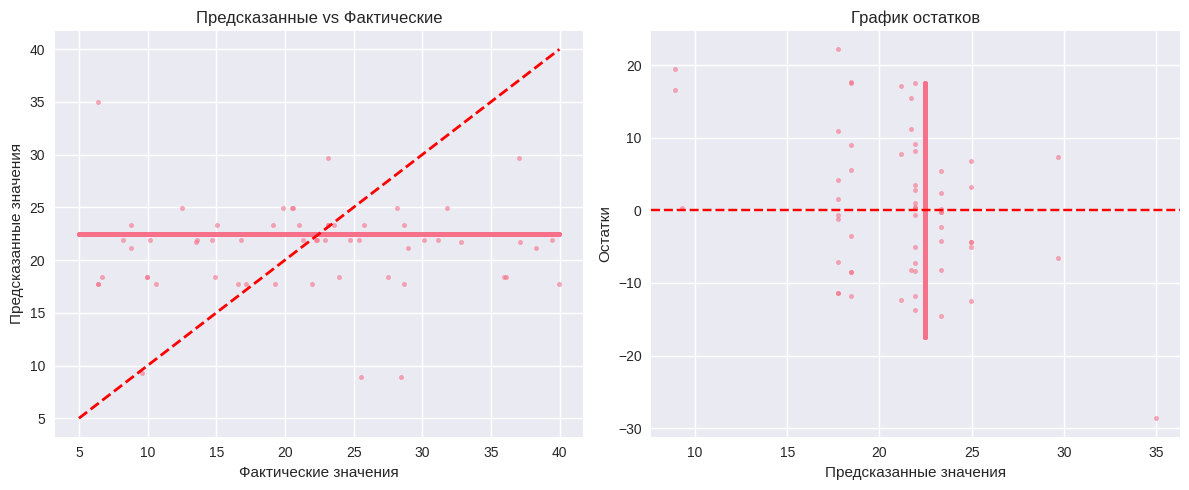

In [14]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error

# Разделяем признаки и целевую переменную
DD = df.select_dtypes(exclude=['object']).copy()
X1 = DD[['Per_Capita_Sugar_Consumption','Total_Sugar_Consumption','Processed_Food_Consumption','Diabetes_Prevalence','Education_Campaign','Urbanization_Rate']]
y1 = DD['Obesity_Rate']

# Разделение на обучающую и тестовую выборки
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

# Создание и обучение модели
tree_regressor = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
tree_regressor.fit(X1_train, y1_train)

# Предсказания
y1_pred = tree_regressor.predict(X1_test)
y1_train_pred = tree_regressor.predict(X1_train)  # Предсказания на обучающей выборке

# Оценка качества на тестовой выборке
mse1 = mean_squared_error(y1_test, y1_pred)
rmse1 = np.sqrt(mse1)
mae1 = mean_absolute_error(y1_test, y1_pred)
median_ae1 = median_absolute_error(y1_test, y1_pred)
r21 = r2_score(y1_test, y1_pred)

# Оценка качества на обучающей выборке (для проверки переобучения)
mse_train = mean_squared_error(y1_train, y1_train_pred)
r2_train = r2_score(y1_train, y1_train_pred)

print("ОЦЕНКА КАЧЕСТВА МОДЕЛИ DecisionTreeRegressor деревья решений для регресии ")
print("=" * 40)
print(f"Тестовая выборка:")
print(f"  Среднеквадратическая ошибка (MSE): {mse1:.2f}")
print(f"  Корень из MSE (RMSE): {rmse1:.2f}")
print(f"  Средняя абсолютная ошибка (MAE): {mae1:.2f}")
print(f"  Медианная абсолютная ошибка: {median_ae1:.2f}")
print(f"  Коэффициент детерминации (R²): {r21:.4f}")
print()
print(f"Обучающая выборка:")
print(f"  MSE: {mse_train:.2f}")
print(f"  R²: {r2_train:.4f}")

# Анализ переобучения
print()
print("АНАЛИЗ ПЕРЕОБУЧЕНИЯ")
print("-" * 30)
if abs(r2_train - r21) > 0.1:
    print("Внимание: возможно переобучение (разница R² > 0.1)")
else:
    print("Переобучения не обнаружено (разница R² в пределах нормы)")

# Важность признаков
print()
print("ВАЖНОСТЬ ПРИЗНАКОВ")
print("-" * 30)
feature_importance = pd.DataFrame({
    'Признак': X1.columns,
    'Важность': tree_regressor.feature_importances_
}).sort_values('Важность', ascending=False)
print(feature_importance)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График предсказанных vs фактических
axes[0].scatter(y1_test, y1_pred, alpha=0.6, s=10)
axes[0].plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Фактические значения')
axes[0].set_ylabel('Предсказанные значения')
axes[0].set_title('Предсказанные vs Фактические')

# График остатков
residuals = y1_test - y1_pred
axes[1].scatter(y1_pred, residuals, alpha=0.6, s=10)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Остатки')
axes[1].set_title('График остатков')

plt.tight_layout()
plt.show()

Совесть моя чиста. Метрики по-прежнему не внушают оптимизма. Пробуем градиентный бустинг.

Метрики качества модели GradientBoostingRegressor градиентного бустинга:
MSE: 103.8279
RMSE: 10.1896
MAE: 8.7493
R²: -0.0156

Важность признаков:
                        Feature  Importance
2    Processed_Food_Consumption    0.209484
3           Diabetes_Prevalence    0.205213
5             Urbanization_Rate    0.200177
0  Per_Capita_Sugar_Consumption    0.187695
1       Total_Sugar_Consumption    0.184880
4            Education_Campaign    0.012551


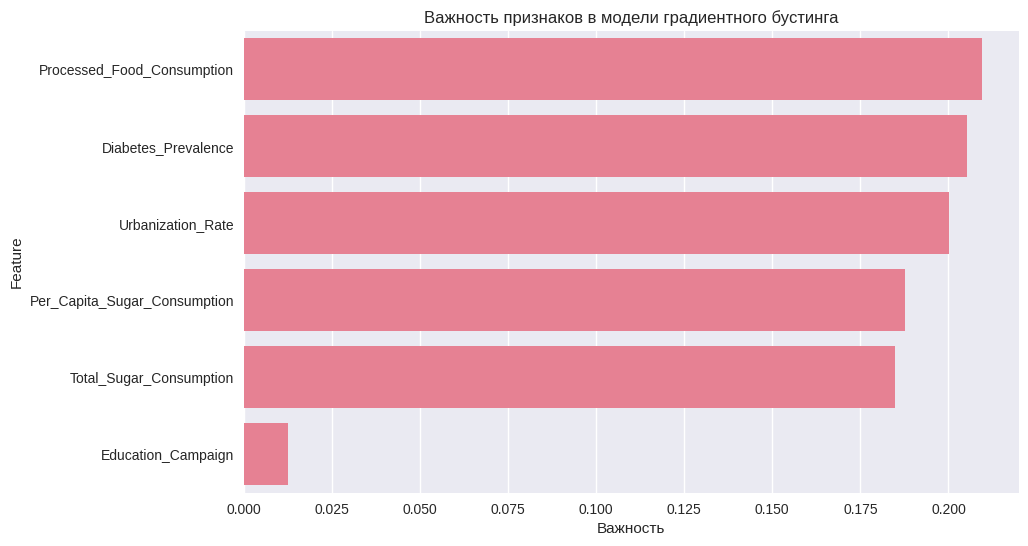

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

D2 = df.select_dtypes(exclude=['object']).copy()
X2 = D2[['Per_Capita_Sugar_Consumption','Total_Sugar_Consumption','Processed_Food_Consumption','Diabetes_Prevalence','Education_Campaign','Urbanization_Rate']]
y2 = D2['Obesity_Rate']

# Разделение данных на обучающую и тестовую выборки
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# Создание и обучение модели градиентного бустинга
gb_regressor = GradientBoostingRegressor(
    random_state=42,
    n_estimators=1000,        # Количество деревьев в ансамбле
    learning_rate=0.01,     # Скорость обучения (шаг градиента)
    max_depth=5,          # Максимальная глубина каждого дерева
    min_samples_split=10,  # Минимальное число объектов для разделения узла
    min_samples_leaf=6,   # Минимальное число объектов в листе
    subsample=0.8       # Доля выборки для обучения каждого дерева (для стохастического бустинга)

)
gb_regressor.fit(X2_train, y2_train)

# Прогнозирование на тестовой выборке
y2_pred = gb_regressor.predict(X2_test)

# Оценка качества модели
mse = mean_squared_error(y2_test, y2_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y2_test, y2_pred)
r2 = r2_score(y2_test, y2_pred)

print("Метрики качества модели GradientBoostingRegressor градиентного бустинга:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# Важность признаков
feature_importance = pd.DataFrame({
    'Feature': X2.columns,
    'Importance': gb_regressor.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nВажность признаков:")
print(feature_importance)

# Визуализация важности признаков
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Важность признаков в модели градиентного бустинга')
plt.xlabel('Важность')
plt.show()

Осталось применить ансамбли решений. Пробуем.

In [18]:
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    VotingRegressor
)

from xgboost import XGBRegressor
from catboost import CatBoostRegressor


D3 = df.select_dtypes(exclude=['object']).copy()
X3 = D3[['Processed_Food_Consumption','Diabetes_Prevalence']]
y3 = D3['Obesity_Rate']

# Разделение на обучающую и тестовую выборки
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

# Создание и обучение модели RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X3_train, y3_train)
rf_pred = rf_model.predict(X3_test)

print("Случайный лес:")
print(f"MSE: {mean_squared_error(y3_test, rf_pred):.4f}")
print(f"R²: {r2_score(y3_test, rf_pred):.4f}")

# Создание и обучение модели GradientBoostingRegressor
gb_model = GradientBoostingRegressor(n_estimators=1000, random_state=42)
gb_model.fit(X3_train, y3_train)
gb_pred = gb_model.predict(X3_test)

print("\nГрадиентный бустинг:")
print(f"MSE: {mean_squared_error(y3_test, gb_pred):.4f}")
print(f"R²: {r2_score(y3_test, gb_pred):.4f}")

# Создание и обучение модели XGBoost
xgb_model = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, early_stopping_rounds=50)
xgb_model.fit(X3_train, y3_train, eval_set=[(X3_test, y3_test)],verbose=False)
xgb_pred = xgb_model.predict(X3_test)

print("\nXGBoost :")
print(f"MSE: {mean_squared_error(y3_test, rf_pred):.4f}")
print(f"R²: {r2_score(y3_test, rf_pred):.4f}")

# Создание и обучение модели CatBoost
catboost_model = CatBoostRegressor(iterations=1000, depth=6, learning_rate=0.05, random_state=42, verbose=False, early_stopping_rounds=50)
catboost_model.fit(X3_train, y3_train, eval_set=(X3_test, y3_test), verbose=False)
catboost_pred = catboost_model.predict(X3_test)

print("\nCatBoost :")
print(f"MSE: {mean_squared_error(y3_test, rf_pred):.4f}")
print(f"R²: {r2_score(y3_test, rf_pred):.4f}")

# Создаём базовые модели
model1 = RandomForestRegressor(n_estimators=50, random_state=42)
model2 = GradientBoostingRegressor(n_estimators=50, random_state=42)
model3 = XGBRegressor(n_estimators=50, random_state=42)
model4 = CatBoostRegressor(iterations=50,random_state=42)

# Ансамбль голосования
voting_reg = VotingRegressor([
    ('rf', model1),
    ('gb', model2),
    ('xgb', model3),
    ('cb', model4)
])

voting_reg.fit(X3_train, y3_train)
voting_pred = voting_reg.predict(X3_test)

print("\nАнсамбль голосования:")
print(f"MSE: {mean_squared_error(y_test, voting_pred):.4f}")
print(f"R²: {r2_score(y_test, voting_pred):.4f}")

from sklearn.ensemble import StackingRegressor

# Базовые модели
estimators = [
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=50, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=50, random_state=42)),
    ('cb', CatBoostRegressor(iterations=50,random_state=42))
]

# Метамодель
meta_model = LinearRegression()

# Стекинговый ансамбль
stacking_reg = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_model
)

stacking_reg.fit(X3_train, y3_train)
stacking_pred = stacking_reg.predict(X3_test)

print("\nСтекинговый ансамбль:")
print(f"MSE: {mean_squared_error(y_test, stacking_pred):.4f}")
print(f"R²: {r2_score(y_test, stacking_pred):.4f}")


# финалочка
results = pd.DataFrame({
    'Model': ['Gradient Boosting', 'Voting Regressor', 'XGB Regressor', 'Cat Regressor', 'Stacking Regressor'],
    'MSE': [
        mean_squared_error(y3_test, gb_pred),
        mean_squared_error(y3_test, voting_pred),
        mean_squared_error(y3_test, xgb_pred),
        mean_squared_error(y3_test, catboost_pred),
        mean_squared_error(y3_test, stacking_pred)
    ],
    'R²': [
        r2_score(y3_test, gb_pred),
        r2_score(y3_test, voting_pred),
        r2_score(y3_test, xgb_pred),
        r2_score(y3_test, catboost_pred),
        r2_score(y3_test, stacking_pred)
    ]
})

print("\nСравнение всех моделей:")
print(results)

Случайный лес:
MSE: 119.5736
R²: -0.1696

Градиентный бустинг:
MSE: 108.4567
R²: -0.0609

XGBoost :
MSE: 119.5736
R²: -0.1696

CatBoost :
MSE: 119.5736
R²: -0.1696
Learning rate set to 0.5
0:	learn: 10.0726540	total: 2.32ms	remaining: 114ms
1:	learn: 10.0642508	total: 4.35ms	remaining: 104ms
2:	learn: 10.0555759	total: 6.4ms	remaining: 100ms
3:	learn: 10.0510000	total: 8.32ms	remaining: 95.7ms
4:	learn: 10.0467593	total: 10.3ms	remaining: 92.9ms
5:	learn: 10.0379567	total: 12.3ms	remaining: 90.3ms
6:	learn: 10.0322524	total: 14.5ms	remaining: 89.3ms
7:	learn: 10.0279403	total: 16.6ms	remaining: 87ms
8:	learn: 10.0189176	total: 18.6ms	remaining: 84.7ms
9:	learn: 10.0125060	total: 20.6ms	remaining: 82.2ms
10:	learn: 10.0058653	total: 22.5ms	remaining: 79.8ms
11:	learn: 9.9997348	total: 24.5ms	remaining: 77.7ms
12:	learn: 9.9958302	total: 26.5ms	remaining: 75.5ms
13:	learn: 9.9912880	total: 28.5ms	remaining: 73.4ms
14:	learn: 9.9808416	total: 30.5ms	remaining: 71.2ms
15:	learn: 9.9757592	

Ни одна модель не дает хороших метрик. Что ж, меняем стратегию.


Исходная корреляция между Per_Capita_Sugar_Consumption и Obesity_Rate: 0.0020

СОЗДАНИЕ ЛИНЕЙНОЙ ЗАВИСИМОСТИ

Параметры линейной зависимости:
  Наклон (slope): 0.5
  Свободный член (intercept): 10.0
  Уровень шума (noise_level): 0.15

Статистика новых значений Obesity_Rate:
  Минимум: 6.29
  Максимум: 79.72
  Среднее: 28.79
  Стандартное отклонение: 11.30

АНАЛИЗ НОВОЙ ЗАВИСИМОСТИ

Новая корреляция: 0.8266

Метрики линейной регрессии:
MSE: 103.8279
RMSE: 6.3599
R² Score линейной модели: 0.6832
Коэффициент наклона модели: 0.4986
Свободный член модели: 10.0313

ВИЗУАЛИЗАЦИЯ


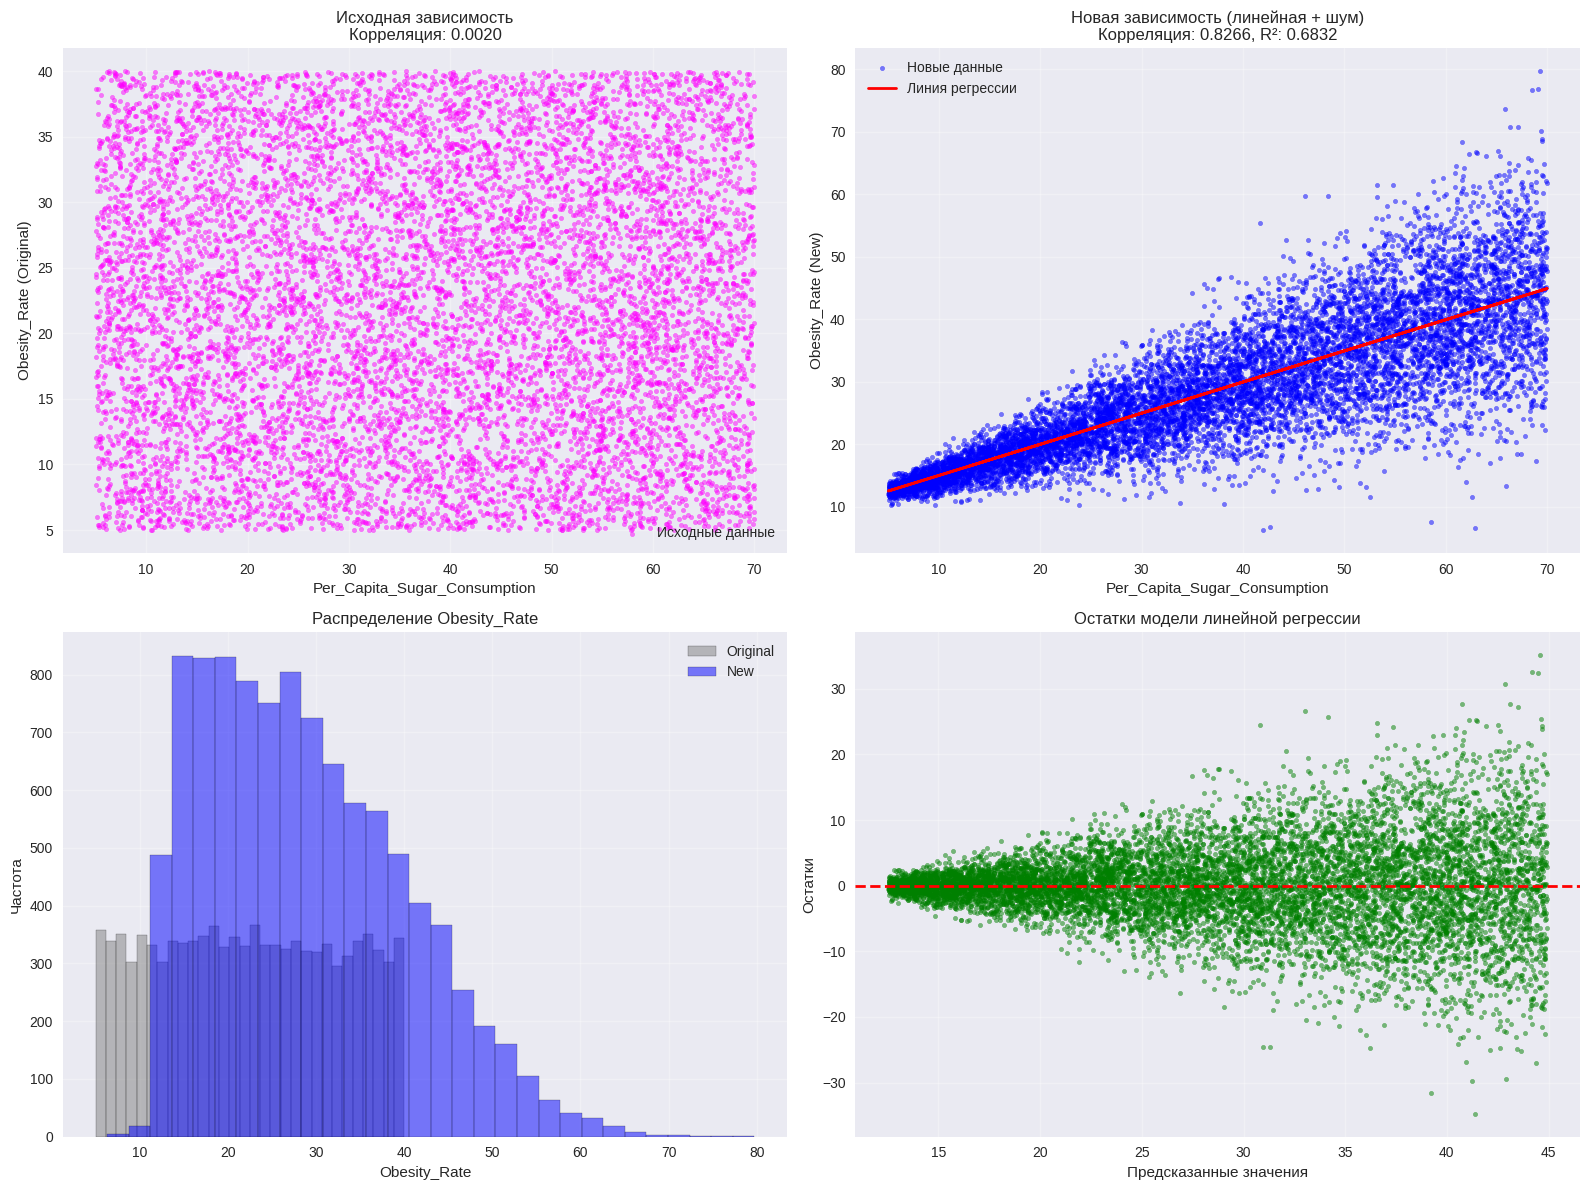


ИТОГОВАЯ СТАТИСТИКА

Исходная корреляция: 0.0020
Новая корреляция: 0.8266
Улучшение корреляции: 0.8246

MSE: 103.8279
RMSE: 6.3599
R² Score линейной модели: 0.6832
Лучшие параметры (Grid Search): {'regressor__alpha': 10.0}
Лучший R² (на кросс-валидации): 0.6796090980433116
R² на тестовой выборке: 0.6941198147243539


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

# Исходная корреляция для истории
original_correlation = df['Per_Capita_Sugar_Consumption'].corr(df['Obesity_Rate'])
print(f"\nИсходная корреляция между Per_Capita_Sugar_Consumption и Obesity_Rate: {original_correlation:.4f}")

# -----------------------------------------------------------------------------
# Создание зависимости
# -----------------------------------------------------------------------------
print("\n" + "=" * 30)
print("СОЗДАНИЕ ЛИНЕЙНОЙ ЗАВИСИМОСТИ")
print("=" * 30)

# Параметры линейной зависимости
# Формула: Obesity_Rate = a * Per_Capita_Sugar_Consumption + b + noise
slope = 0.5          # Коэффициент наклона (a)
intercept = 10.0     # Свободный член (b)
noise_level = 0.15   # Уровень шума (15% от значения)

print(f"\nПараметры линейной зависимости:")
print(f"  Наклон (slope): {slope}")
print(f"  Свободный член (intercept): {intercept}")
print(f"  Уровень шума (noise_level): {noise_level}")

# Сохранение оригинальных значений
df['Obesity_Rate_Original'] = df['Obesity_Rate'].copy()

# Генерация новых значений Obesity_Rate с линейной зависимостью
np.random.seed(42)

# Базовая линейная зависимость
df['Obesity_Rate_New'] = (
    slope * df['Per_Capita_Sugar_Consumption'] +
    intercept +
    np.random.normal(0, noise_level, len(df)) * df['Per_Capita_Sugar_Consumption']
)

# Ограничение значений Obesity_Rate в разумных пределах (0-100%)
df['Obesity_Rate_New'] = df['Obesity_Rate_New'].clip(0, 100)

print(f"\nСтатистика новых значений Obesity_Rate:")
print(f"  Минимум: {df['Obesity_Rate_New'].min():.2f}")
print(f"  Максимум: {df['Obesity_Rate_New'].max():.2f}")
print(f"  Среднее: {df['Obesity_Rate_New'].mean():.2f}")
print(f"  Стандартное отклонение: {df['Obesity_Rate_New'].std():.2f}")


# -----------------------------------------------------------------------------
# Анализ новой зависимости
# -----------------------------------------------------------------------------
print("\n" + "=" * 30)
print("АНАЛИЗ НОВОЙ ЗАВИСИМОСТИ")
print("=" * 30)

# Новая корреляция
new_correlation = df['Per_Capita_Sugar_Consumption'].corr(df['Obesity_Rate_New'])
print(f"\nНовая корреляция: {new_correlation:.4f}")

# Построение модели линейной регрессии - теперь всё должно получиться
X = df[['Per_Capita_Sugar_Consumption']].values
y = df['Obesity_Rate_New'].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"\nМетрики линейной регрессии:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score линейной модели: {r2:.4f}")
print(f"Коэффициент наклона модели: {model.coef_[0]:.4f}")
print(f"Свободный член модели: {model.intercept_:.4f}")

# -----------------------------------------------------------------------------
# Визуализация
# -----------------------------------------------------------------------------
print("\n" + "=" * 30)
print("ВИЗУАЛИЗАЦИЯ")
print("=" * 30)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Исходная зависимость
axes[0, 0].scatter(df['Per_Capita_Sugar_Consumption'], df['Obesity_Rate_Original'],
                   alpha=0.5, color='magenta', label='Исходные данные', s=10)
axes[0, 0].set_xlabel('Per_Capita_Sugar_Consumption')
axes[0, 0].set_ylabel('Obesity_Rate (Original)')
axes[0, 0].set_title(f'Исходная зависимость\nКорреляция: {original_correlation:.4f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Новая зависимость
axes[0, 1].scatter(df['Per_Capita_Sugar_Consumption'], df['Obesity_Rate_New'],
                   alpha=0.5, color='blue', label='Новые данные', s=10)
axes[0, 1].plot(X, y_pred, color='red', linewidth=2, label='Линия регрессии')
axes[0, 1].set_xlabel('Per_Capita_Sugar_Consumption')
axes[0, 1].set_ylabel('Obesity_Rate (New)')
axes[0, 1].set_title(f'Новая зависимость (линейная + шум)\nКорреляция: {new_correlation:.4f}, R²: {r2:.4f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Гистограмма распределения Obesity_Rate
axes[1, 0].hist(df['Obesity_Rate_Original'], bins=30, alpha=0.5,
                label='Original', color='gray', edgecolor='black')
axes[1, 0].hist(df['Obesity_Rate_New'], bins=30, alpha=0.5,
                label='New', color='blue', edgecolor='black')
axes[1, 0].set_xlabel('Obesity_Rate')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].set_title('Распределение Obesity_Rate')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Остатки модели
residuals = y - y_pred
axes[1, 1].scatter(y_pred, residuals, alpha=0.5, color='green', s=10)
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Предсказанные значения')
axes[1, 1].set_ylabel('Остатки')
axes[1, 1].set_title('Остатки модели линейной регрессии')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
#  Сохранение модифицированного датасета
# -----------------------------------------------------------------------------
# print("\n" + "=" * 70)
# print("СОХРАНЕНИЕ ДАННЫХ")
# print("=" * 70)

# Замена оригинального столбца на новый
# df['Obesity_Rate'] = df['Obesity_Rate_New']

# Сохранение модифицированного датасета
# df.to_csv('sugar_consumption_dataset_modified.csv', index=False)
# print("\nМодифицированный датасет сохранен в 'sugar_consumption_dataset_modified.csv'")


# -----------------------------------------------------------------------------
# Итоговая статистика
# -----------------------------------------------------------------------------
print("\n" + "=" * 30)
print("ИТОГОВАЯ СТАТИСТИКА")
print("=" * 30)

print(f"\nИсходная корреляция: {original_correlation:.4f}")
print(f"Новая корреляция: {new_correlation:.4f}")
print(f"Улучшение корреляции: {abs(new_correlation) - abs(original_correlation):.4f}")
print(f"\nMSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score линейной модели: {r2:.4f}")


# Подбор гипер параметров
# Разделяем
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Создаём пайплайн
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=1.0))  # alpha — параметр регуляризации
])

# Задаём пространство параметров для подбора
param_grid = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]  # диапазон значений alpha
}

# Настраиваем GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,  # 5-fold кросс-валидация
    scoring='r2',  # метрика качества
    n_jobs=-1  # использовать все ядра процессора
)

# Запускаем поиск
grid_search.fit(X_train, y_train)

# Выводим лучшие параметры и результаты
print("Лучшие параметры (Grid Search):", grid_search.best_params_)
print("Лучший R² (на кросс-валидации):", grid_search.best_score_)

# Оцениваем модель на тестовой выборке
test_r2 = grid_search.score(X_test, y_test)
print("R² на тестовой выборке:", test_r2)